# Business Revenue Regression

This notebook presents a complete machine learning pipeline to predict `annual_revenue` for businesses based on various operational, demographic, and marketing features. The pipeline covers data loading, exploratory data analysis, data cleaning, feature engineering, model training with multiple algorithms, hyperparameter tuning, evaluation, and model persistence.

---
## 1. Import Libraries

All required libraries are imported here. This includes libraries for data manipulation, visualization, preprocessing, model building, evaluation, and model persistence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import os
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42

---
## 2. Load Dataset

The dataset is loaded from the CSV file located in the `Dataset` directory. An initial inspection is performed to understand the structure, data types, and basic statistics.

In [2]:
df = pd.read_csv('../Dataset/dataset.csv')

print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
df.head(10)

Dataset Shape: 1200 rows x 13 columns



,age,experience_years,experience_proxy,monthly_ad_spend,website_visits,team_size,customer_rating,region,business_type,subscription_plan,noise_feature_1,noise_feature_2,annual_revenue
0,23,0,-1.28,120217.22,394762,8,4.01,Alexandria,Ecommerce,Standard,-294.95,-18.61,240086.12
1,51,29,28.75,54622.52,183214,56,2.89,Cairo,Services,Basic,-461.02,44.49,274237.97
2,46,20,23.79,41675.76,113096,141,2.89,Upper_Egypt,Manufacturing,Basic,-2156.89,-15.63,294387.86
3,37,13,15.73,13457.42,41326,91,4.64,Cairo,Services,Standard,682.77,21.51,247522.89
4,37,14,13.88,9281.03,11671,93,3.28,Cairo,Services,Standard,-1233.05,38.27,226068.17
5,55,29,29.40,32526.42,113516,14,4.08,Upper_Egypt,Services,Premium,63.27,-32.92,187301.14
6,23,1,-0.46,7884.32,25290,78,4.07,Upper_Egypt,Services,Standard,-808.27,-29.44,144108.28
7,48,24,22.24,15052.51,18275,59,4.60,Upper_Egypt,Manufacturing,Premium,-388.73,8.10,237855.46
8,28,8,8.09,16515.32,43286,73,4.35,Upper_Egypt,Retail,Basic,1152.29,34.38,157936.72
9,23,0,-1.30,59445.26,165535,40,4.60,Cairo,Services,Standard,531.62,-42.11,220319.78


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1200 non-null   int64  
 1   experience_years   1200 non-null   int64  
 2   experience_proxy   1200 non-null   float64
 3   monthly_ad_spend   1200 non-null   float64
 4   website_visits     1200 non-null   int64  
 5   team_size          1200 non-null   int64  
 6   customer_rating    1200 non-null   float64
 7   region             1200 non-null   str    
 8   business_type      1200 non-null   str    
 9   subscription_plan  1200 non-null   str    
 10  noise_feature_1    1200 non-null   float64
 11  noise_feature_2    1200 non-null   float64
 12  annual_revenue     1200 non-null   float64
dtypes: float64(6), int64(4), str(3)
memory usage: 147.5 KB


In [4]:
df.describe()

,age,experience_years,experience_proxy,monthly_ad_spend,website_visits,team_size,customer_rating,noise_feature_1,noise_feature_2,annual_revenue
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,40.162500,18.307500,18.779933,24208.585867,65729.14000,74.217500,3.755708,-49.640983,-1.071300,233149.783258
std,11.797333,11.743986,12.174497,20618.049145,57825.13094,42.933724,0.714649,974.443011,28.532477,49740.754481
min,20.000000,0.000000,-2.940000,2104.830000,1000.00000,2.000000,2.500000,-2974.400000,-49.980000,102938.820000
25%,30.000000,7.750000,7.937500,10991.792500,29632.25000,38.000000,3.160000,-708.180000,-25.800000,198259.660000
50%,40.000000,19.000000,19.095000,18147.650000,49457.50000,72.000000,3.780000,-38.625000,-1.710000,232717.490000
75%,51.000000,28.000000,28.915000,31169.412500,83946.75000,111.000000,4.350000,564.887500,23.482500,266027.432500
max,60.000000,38.000000,42.130000,180000.000000,544599.00000,150.000000,5.000000,4151.240000,49.970000,415128.670000


In [5]:
df.describe(include='object')

,region,business_type,subscription_plan
count,1200,1200,1200
unique,4,4,3
top,Cairo,Retail,Basic
freq,506,366,525


---
## 3. Data Cleaning

This section addresses missing values, duplicate records, and data type inconsistencies to ensure the dataset is ready for analysis and modeling.

### 3.1 Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_pct
})
missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Missing Percentage (%)


In [7]:
if df.isnull().sum().sum() == 0:
    print('No missing values found in the dataset.')
else:
    print(f'Total missing values: {df.isnull().sum().sum()}')
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
    print('Missing values have been imputed (median for numerical, mode for categorical).')

No missing values found in the dataset.


### 3.2 Duplicate Records

In [8]:
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicate rows found.')

Number of duplicate rows: 0
No duplicate rows found.


### 3.3 Data Type Validation

In [9]:
print('Column Data Types:')
print(df.dtypes)
print()

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')

Column Data Types:
age                    int64
experience_years       int64
experience_proxy     float64
monthly_ad_spend     float64
website_visits         int64
team_size              int64
customer_rating      float64
region                   str
business_type            str
subscription_plan        str
noise_feature_1      float64
noise_feature_2      float64
annual_revenue       float64
dtype: object

Numerical columns (10): ['age', 'experience_years', 'experience_proxy', 'monthly_ad_spend', 'website_visits', 'team_size', 'customer_rating', 'noise_feature_1', 'noise_feature_2', 'annual_revenue']
Categorical columns (3): ['region', 'business_type', 'subscription_plan']


---
## 4. Exploratory Data Analysis (EDA)

A thorough exploratory analysis is conducted to understand the distribution of features, relationships between variables, and the target variable behavior.

### 4.1 Target Variable Distribution

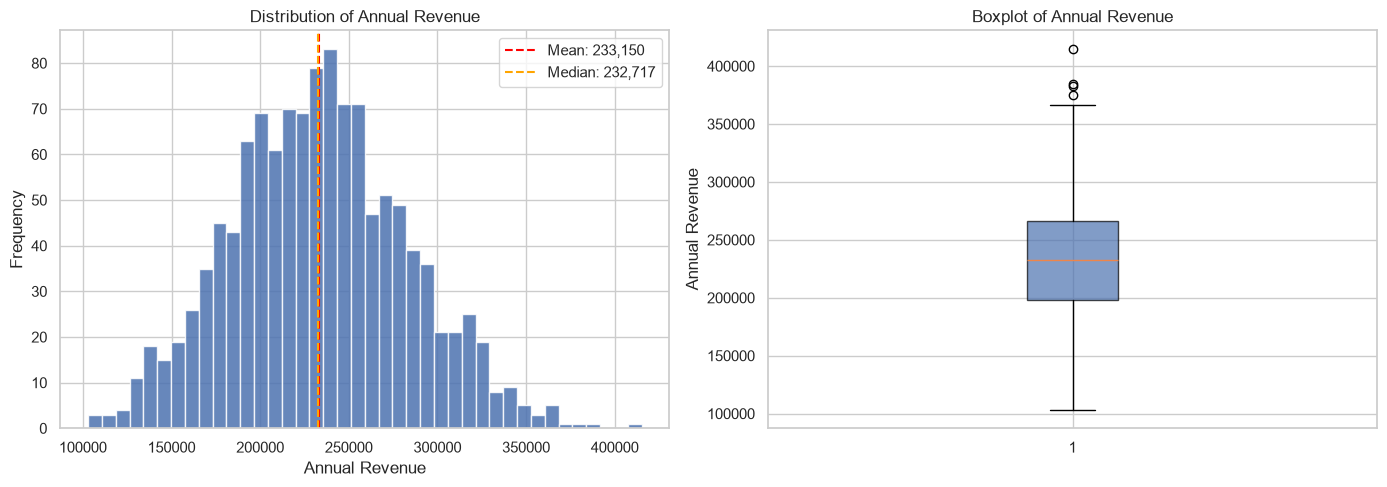

Skewness: 0.1743
Kurtosis: -0.1120


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['annual_revenue'], bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Annual Revenue')
axes[0].set_xlabel('Annual Revenue')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['annual_revenue'].mean(), color='red', linestyle='--', label=f"Mean: {df['annual_revenue'].mean():,.0f}")
axes[0].axvline(df['annual_revenue'].median(), color='orange', linestyle='--', label=f"Median: {df['annual_revenue'].median():,.0f}")
axes[0].legend()

axes[1].boxplot(df['annual_revenue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[1].set_title('Boxplot of Annual Revenue')
axes[1].set_ylabel('Annual Revenue')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['annual_revenue'].skew():.4f}")
print(f"Kurtosis: {df['annual_revenue'].kurtosis():.4f}")

### 4.2 Numerical Feature Distributions

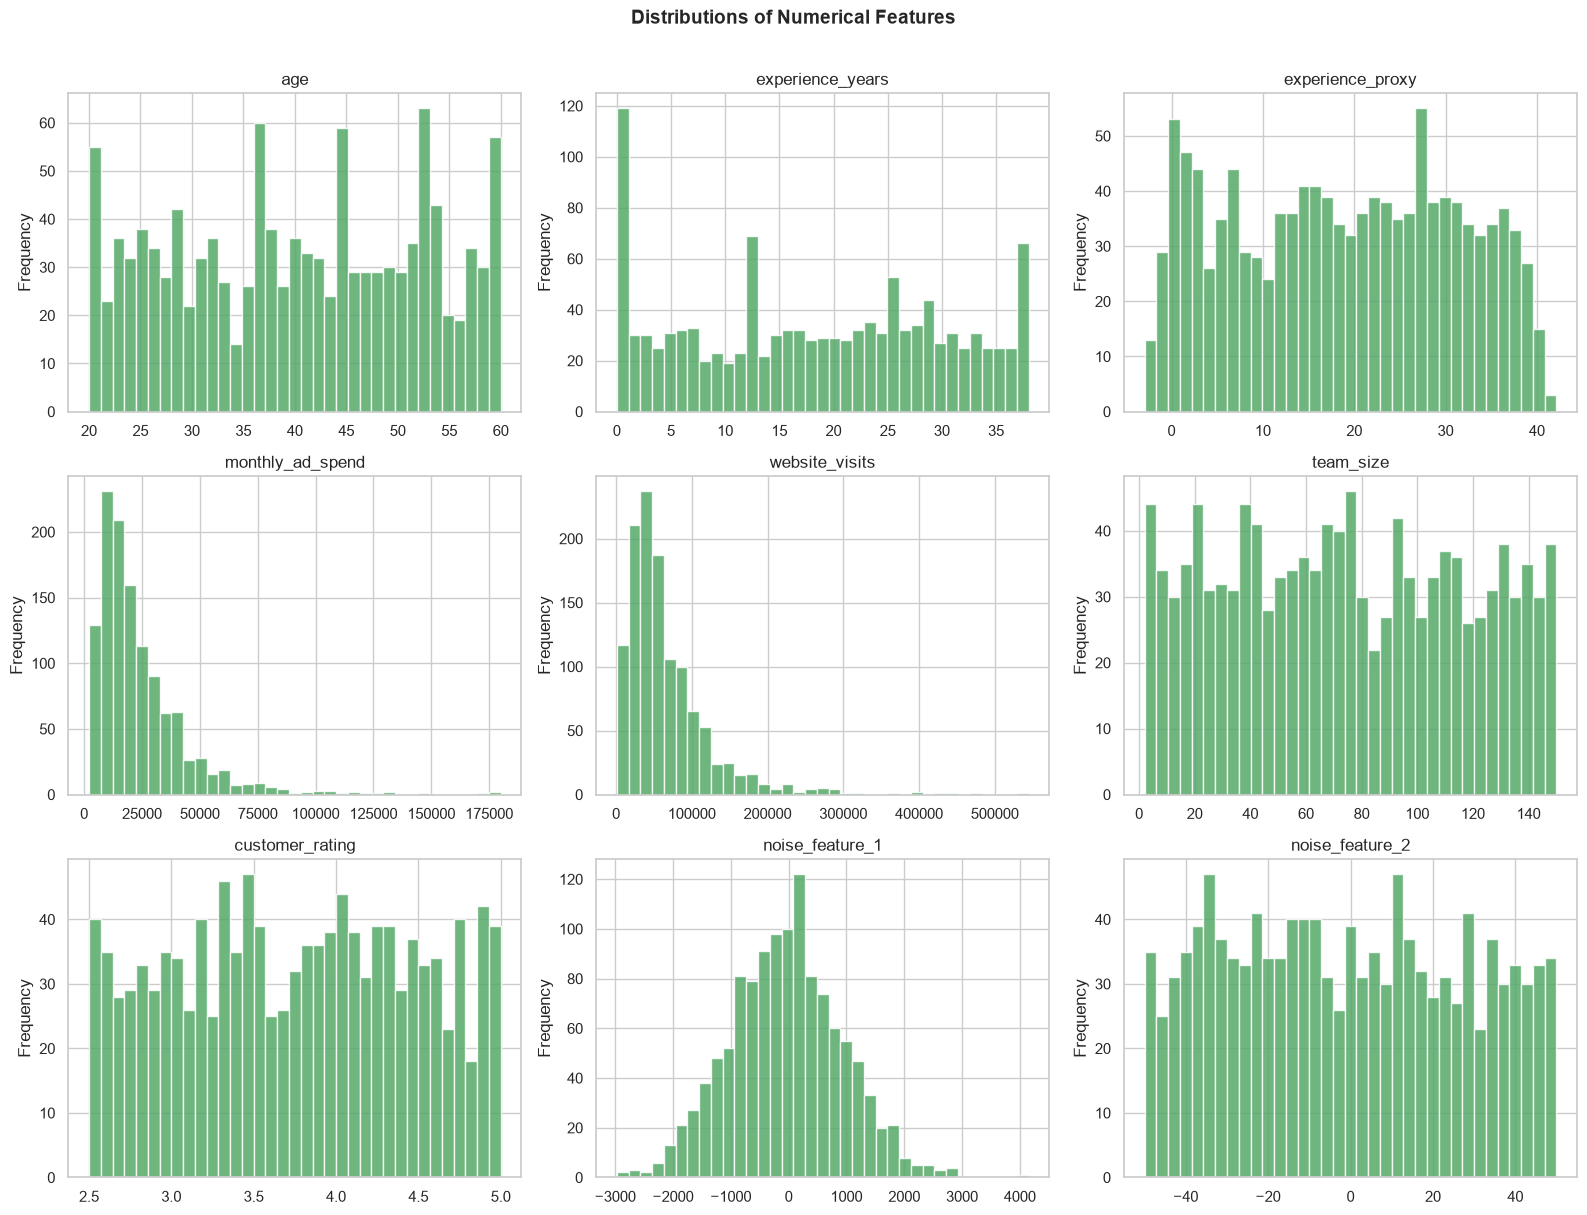

In [11]:
num_features = [c for c in numerical_cols if c != 'annual_revenue']
n_cols_plot = 3
n_rows_plot = (len(num_features) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=35, color='#55A868', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Categorical Feature Distributions

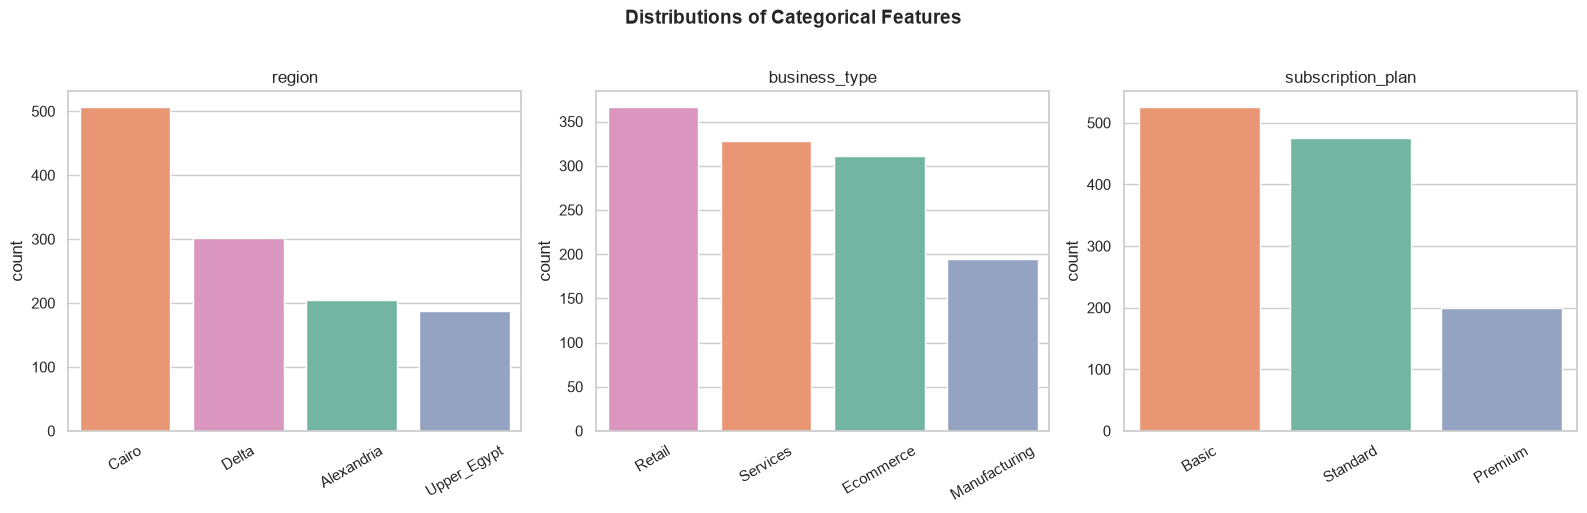

In [12]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(16, 5))

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distributions of Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Correlation Analysis

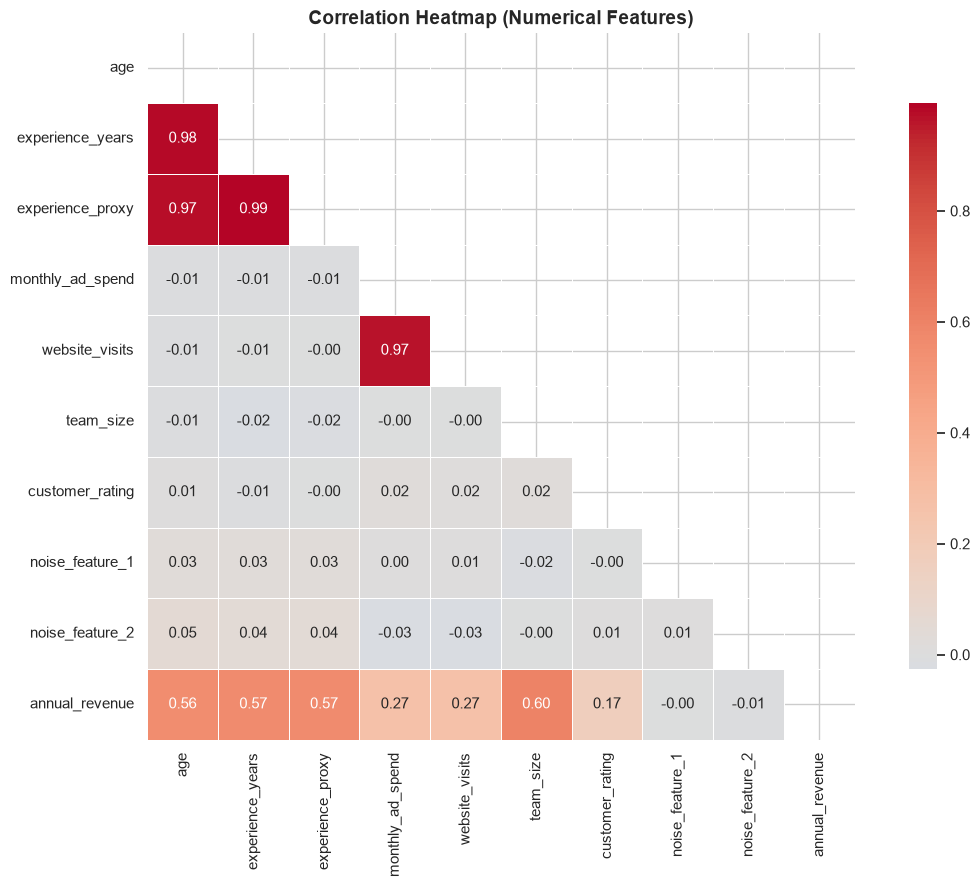

In [13]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
target_corr = corr_matrix['annual_revenue'].drop('annual_revenue').sort_values(ascending=False)
print('Correlation with annual_revenue (sorted by absolute value):')
print(target_corr.reindex(target_corr.abs().sort_values(ascending=False).index))

Correlation with annual_revenue (sorted by absolute value):
team_size           0.599319
experience_proxy    0.565680
experience_years    0.565269
age                 0.558524
monthly_ad_spend    0.271481
website_visits      0.267829
customer_rating     0.166393
noise_feature_2    -0.007660
noise_feature_1    -0.002199
Name: annual_revenue, dtype: float64


### 4.5 Feature vs Target Scatter Plots

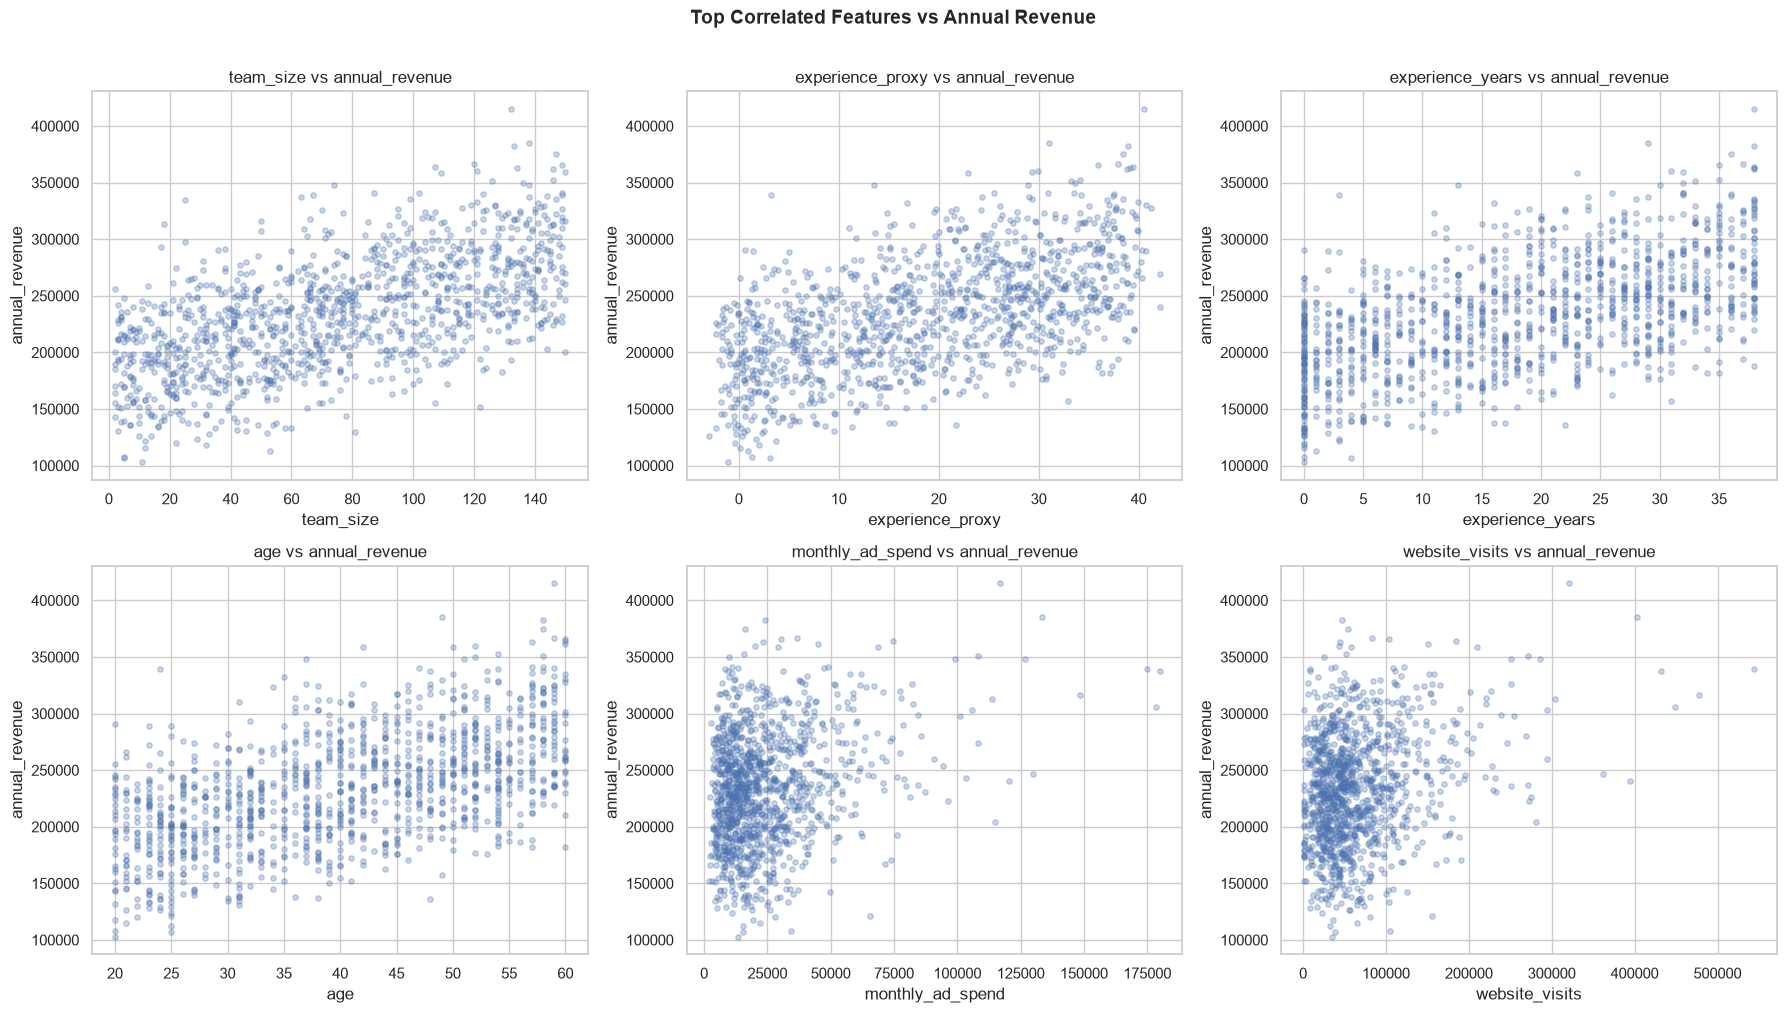

In [15]:
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df['annual_revenue'], alpha=0.3, s=15, color='#4C72B0')
    axes[i].set_title(f'{col} vs annual_revenue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('annual_revenue')

plt.suptitle('Top Correlated Features vs Annual Revenue', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.6 Categorical Features vs Target

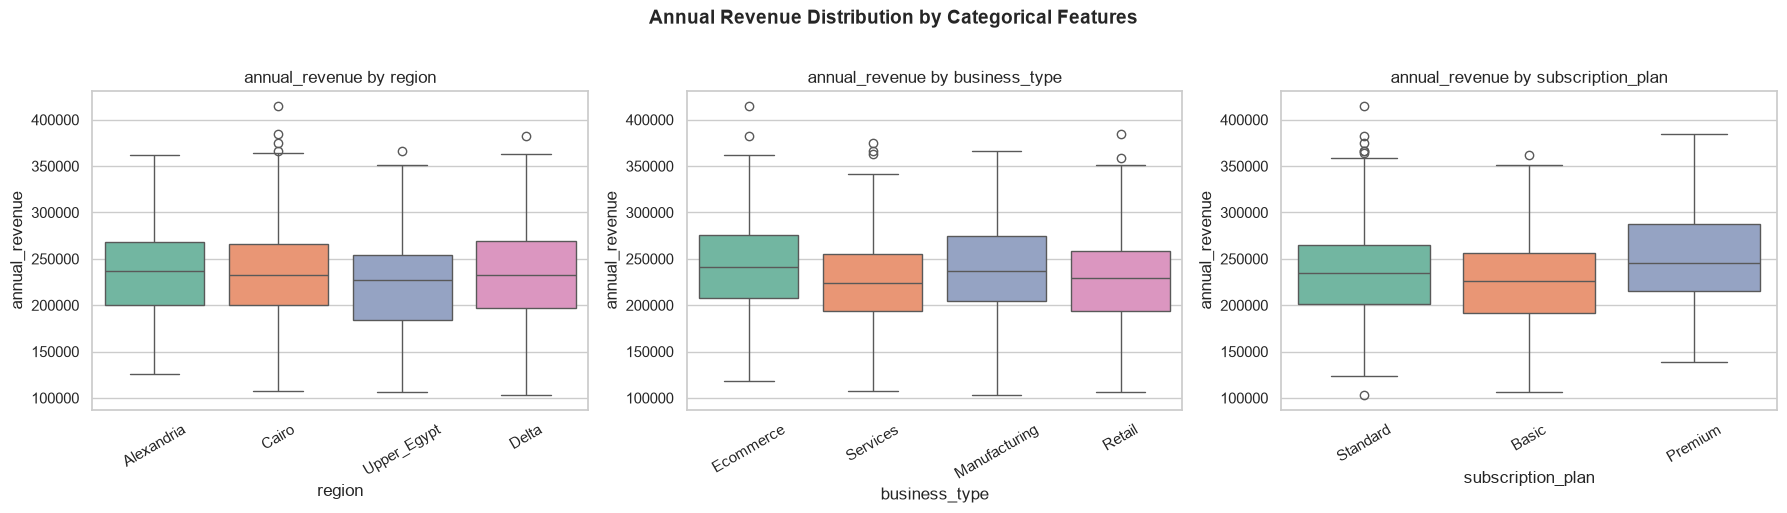

In [16]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 5))

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y='annual_revenue', ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'annual_revenue by {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Annual Revenue Distribution by Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Outlier Detection and Treatment

Outliers in numerical features are identified using the Interquartile Range (IQR) method. Rather than removing outliers, they are capped (winsorized) at the lower and upper bounds to preserve data volume.

In [17]:
outlier_cols = [c for c in numerical_cols if c != 'annual_revenue']

outlier_summary = []
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': n_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,age,30.00,51.00,21.00,-1.50,82.50,0
1,experience_years,7.75,28.00,20.25,-22.62,58.38,0
2,experience_proxy,7.94,28.92,20.98,-23.53,60.38,0
3,monthly_ad_spend,10991.79,31169.41,20177.62,-19274.64,61435.84,60
4,website_visits,29632.25,83946.75,54314.50,-51839.50,165418.50,67
5,team_size,38.00,111.00,73.00,-71.50,220.50,0
6,customer_rating,3.16,4.35,1.19,1.38,6.13,0
7,noise_feature_1,-708.18,564.89,1273.07,-2617.78,2474.49,12
8,noise_feature_2,-25.80,23.48,49.28,-99.72,97.41,0


In [18]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print('Outliers have been capped using IQR-based winsorization.')

Outliers have been capped using IQR-based winsorization.


---
## 6. Feature Engineering

This section creates new features from existing ones and identifies features that should be dropped based on the correlation analysis. The `noise_feature_1` and `noise_feature_2` columns, as implied by their names and typically low correlation with the target, are evaluated for removal.

In [19]:
noise_corr_1 = df['noise_feature_1'].corr(df['annual_revenue'])
noise_corr_2 = df['noise_feature_2'].corr(df['annual_revenue'])

print(f'Correlation of noise_feature_1 with target: {noise_corr_1:.4f}')
print(f'Correlation of noise_feature_2 with target: {noise_corr_2:.4f}')

drop_cols = []
if abs(noise_corr_1) < 0.05:
    drop_cols.append('noise_feature_1')
if abs(noise_corr_2) < 0.05:
    drop_cols.append('noise_feature_2')

if drop_cols:
    df.drop(columns=drop_cols, inplace=True)
    print(f'Dropped noise features: {drop_cols}')
else:
    print('Noise features retained (correlation above threshold).')

print(f'Updated shape: {df.shape}')

Correlation of noise_feature_1 with target: -0.0043
Correlation of noise_feature_2 with target: -0.0077
Dropped noise features: ['noise_feature_1', 'noise_feature_2']
Updated shape: (1200, 11)


In [20]:
df['ad_spend_per_visit'] = df['monthly_ad_spend'] / (df['website_visits'] + 1)
df['revenue_potential'] = df['experience_years'] * df['team_size']
df['experience_rating'] = df['experience_years'] * df['customer_rating']

print('New features created:')
print('  - ad_spend_per_visit: Monthly ad spend divided by website visits (cost per visit)')
print('  - revenue_potential: Experience years multiplied by team size')
print('  - experience_rating: Experience years multiplied by customer rating')
print(f'Updated shape: {df.shape}')

New features created:
  - ad_spend_per_visit: Monthly ad spend divided by website visits (cost per visit)
  - revenue_potential: Experience years multiplied by team size
  - experience_rating: Experience years multiplied by customer rating
Updated shape: (1200, 14)


In [21]:
df.head()

,age,experience_years,experience_proxy,monthly_ad_spend,website_visits,team_size,customer_rating,region,business_type,subscription_plan,annual_revenue,ad_spend_per_visit,revenue_potential,experience_rating
0,23,0,-1.28,61435.8425,165418.5,8,4.01,Alexandria,Ecommerce,Standard,240086.12,0.371394,0,0.00
1,51,29,28.75,54622.5200,165418.5,56,2.89,Cairo,Services,Basic,274237.97,0.330206,1624,83.81
2,46,20,23.79,41675.7600,113096.0,141,2.89,Upper_Egypt,Manufacturing,Basic,294387.86,0.368496,2820,57.80
3,37,13,15.73,13457.4200,41326.0,91,4.64,Cairo,Services,Standard,247522.89,0.325633,1183,60.32
4,37,14,13.88,9281.0300,11671.0,93,3.28,Cairo,Services,Standard,226068.17,0.795153,1302,45.92


---
## 7. Data Preparation for Modeling

The data is split into features and target, then divided into training and test sets. A preprocessing pipeline is built with `StandardScaler` for numerical features and `OneHotEncoder` for categorical features.

In [22]:
X = df.drop(columns=['annual_revenue'])
y = df['annual_revenue']

numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Feature matrix shape: {X.shape}')
print(f'Numerical features ({len(numerical_features)}): {numerical_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Feature matrix shape: (1200, 13)
Numerical features (10): ['age', 'experience_years', 'experience_proxy', 'monthly_ad_spend', 'website_visits', 'team_size', 'customer_rating', 'ad_spend_per_visit', 'revenue_potential', 'experience_rating']
Categorical features (3): ['region', 'business_type', 'subscription_plan']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 960 samples
Test set: 240 samples


In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

print('Preprocessing pipeline created:')
print('  - Numerical features: StandardScaler')
print('  - Categorical features: OneHotEncoder (drop first category)')

Preprocessing pipeline created:
  - Numerical features: StandardScaler
  - Categorical features: OneHotEncoder (drop first category)


---
## 8. Model Training and Baseline Comparison

Multiple regression algorithms are trained and evaluated using 5-fold cross-validation on the training set. This provides a robust comparison to identify the most promising models before hyperparameter tuning.

In [25]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    r2_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
    neg_mae_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    neg_rmse_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    results.append({
        'Model': name,
        'R2 Mean': r2_scores.mean(),
        'R2 Std': r2_scores.std(),
        'MAE Mean': -neg_mae_scores.mean(),
        'MAE Std': neg_mae_scores.std(),
        'RMSE Mean': -neg_rmse_scores.mean(),
        'RMSE Std': neg_rmse_scores.std()
    })
    print(f'{name:25s} | R2: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f}) | MAE: {-neg_mae_scores.mean():,.0f} | RMSE: {-neg_rmse_scores.mean():,.0f}')

results_df = pd.DataFrame(results).sort_values('R2 Mean', ascending=False).reset_index(drop=True)
results_df

Linear Regression         | R2: 0.8530 (+/- 0.0162) | MAE: 14,842 | RMSE: 18,980


Ridge                     | R2: 0.8533 (+/- 0.0164) | MAE: 14,824 | RMSE: 18,963


Lasso                     | R2: 0.8530 (+/- 0.0162) | MAE: 14,842 | RMSE: 18,979


ElasticNet                | R2: 0.7723 (+/- 0.0229) | MAE: 18,542 | RMSE: 23,643


Decision Tree             | R2: 0.5407 (+/- 0.0330) | MAE: 26,283 | RMSE: 33,540


...

Gradient Boosting         | R2: 0.8179 (+/- 0.0176) | MAE: 16,539 | RMSE: 21,142


AdaBoost                  | R2: 0.7478 (+/- 0.0104) | MAE: 19,408 | RMSE: 24,890


XGBoost                   | R2: 0.7757 (+/- 0.0236) | MAE: 18,201 | RMSE: 23,450


LightGBM                  | R2: 0.8072 (+/- 0.0185) | MAE: 17,058 | RMSE: 21,753


,Model,R2 Mean,R2 Std,MAE Mean,MAE Std,RMSE Mean,RMSE Std
0,Ridge,0.853272,0.016361,14824.368076,875.432107,18963.039257,1379.174852
1,Lasso,0.853028,0.016205,14841.573055,871.789127,18978.867165,1364.649427
2,Linear Regression,0.853007,0.016207,14842.175259,870.898113,18980.121866,1364.025638
3,Gradient Boosting,0.817892,0.017588,16538.918065,1007.698548,21141.830913,1552.032902
4,LightGBM,0.807203,0.018478,17058.111656,959.121865,21753.128176,1586.812676
5,Random Forest,0.777824,0.021608,18151.927582,1045.456340,23346.939985,1607.044693
6,XGBoost,0.775658,0.023576,18200.971964,1022.418915,23450.033952,1596.009117
7,ElasticNet,0.772304,0.022878,18542.373944,1295.679925,23642.666169,1786.006853
8,AdaBoost,0.747775,0.010436,19407.759590,715.839691,24889.919584,1103.775942
9,Decision Tree,0.540671,0.032968,26282.830771,807.261602,33540.493290,927.212648


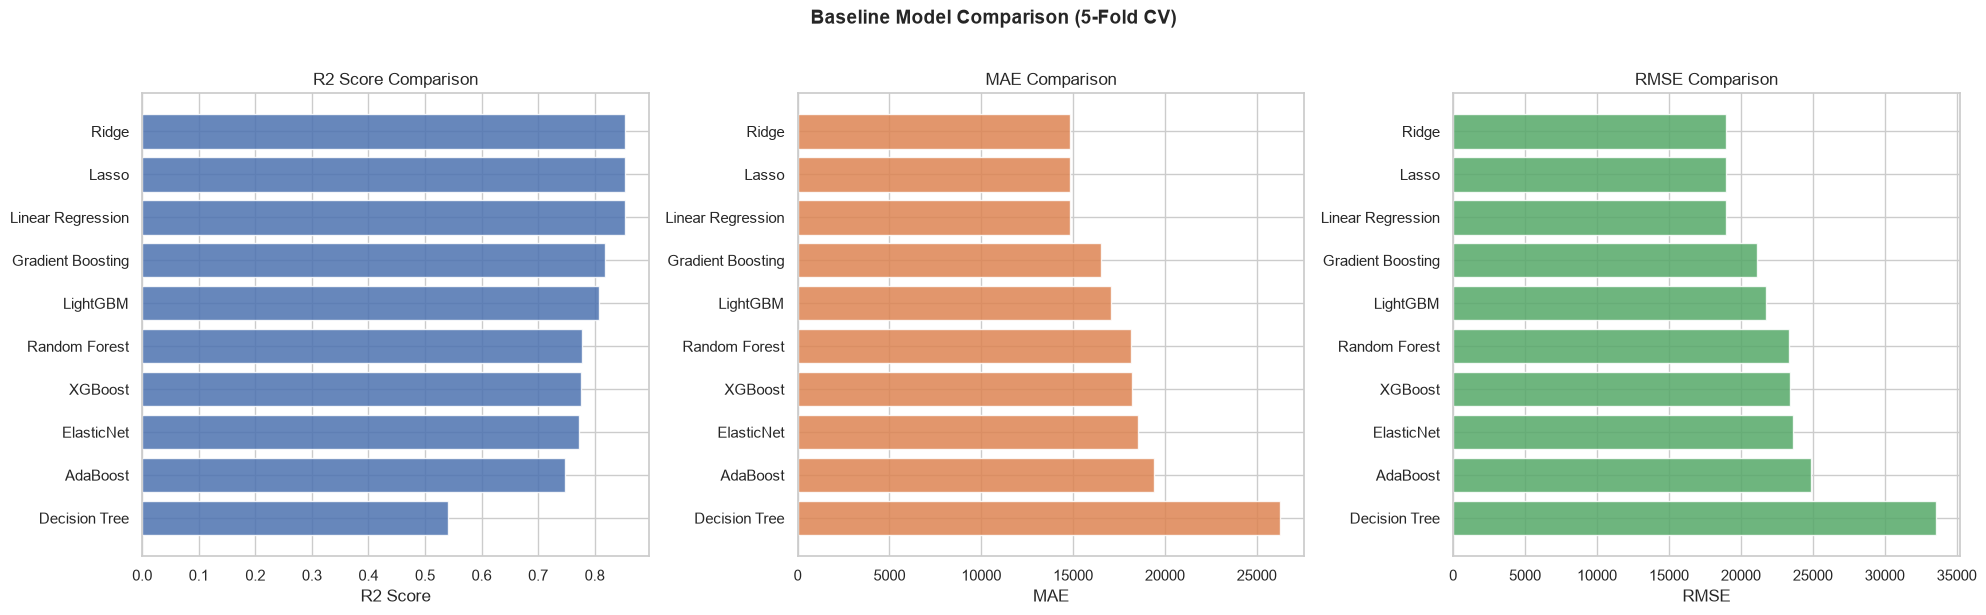

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sorted_df = results_df.sort_values('R2 Mean', ascending=True)

axes[0].barh(sorted_df['Model'], sorted_df['R2 Mean'], color='#4C72B0', alpha=0.85)
axes[0].set_xlabel('R2 Score')
axes[0].set_title('R2 Score Comparison')

axes[1].barh(sorted_df['Model'], sorted_df['MAE Mean'], color='#DD8452', alpha=0.85)
axes[1].set_xlabel('MAE')
axes[1].set_title('MAE Comparison')

axes[2].barh(sorted_df['Model'], sorted_df['RMSE Mean'], color='#55A868', alpha=0.85)
axes[2].set_xlabel('RMSE')
axes[2].set_title('RMSE Comparison')

plt.suptitle('Baseline Model Comparison (5-Fold CV)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Hyperparameter Tuning

The top 3 performing models from the baseline comparison are selected for hyperparameter tuning using `GridSearchCV` with 5-fold cross-validation. This step aims to find the optimal parameter configuration for each model.

In [27]:
top_models = results_df.head(3)['Model'].tolist()
print(f'Top 3 models selected for tuning: {top_models}')

Top 3 models selected for tuning: ['Ridge', 'Lasso', 'Linear Regression']


In [28]:
param_grids = {
    'Random Forest': {
        'regressor__n_estimators': [100, 200, 300],
        'regressor__max_depth': [10, 20, None],
        'regressor__min_samples_split': [2, 5],
        'regressor__min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'regressor__n_estimators': [100, 200, 300],
        'regressor__max_depth': [3, 5, 7],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__subsample': [0.8, 1.0]
    },
    'XGBoost': {
        'regressor__n_estimators': [100, 200, 300],
        'regressor__max_depth': [3, 5, 7],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__subsample': [0.8, 1.0],
        'regressor__colsample_bytree': [0.8, 1.0]
    },
    'LightGBM': {
        'regressor__n_estimators': [100, 200, 300],
        'regressor__max_depth': [5, 10, -1],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__num_leaves': [31, 50, 70]
    },
    'Ridge': {
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'ElasticNet': {
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
        'regressor__l1_ratio': [0.2, 0.5, 0.8]
    },
    'Linear Regression': {},
    'Decision Tree': {
        'regressor__max_depth': [5, 10, 20, None],
        'regressor__min_samples_split': [2, 5, 10],
        'regressor__min_samples_leaf': [1, 2, 4]
    },
    'AdaBoost': {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__learning_rate': [0.01, 0.1, 1.0]
    }
}

tuned_results = []
best_pipelines = {}

for model_name in top_models:
    print(f'\nTuning: {model_name}')
    print('-' * 50)
    
    model_obj = models[model_name]
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model_obj)
    ])
    
    grid = param_grids.get(model_name, {})
    
    if grid:
        search = GridSearchCV(
            pipeline, grid, cv=cv, scoring='r2',
            n_jobs=-1, verbose=0, refit=True
        )
        search.fit(X_train, y_train)
        best_pipelines[model_name] = search.best_estimator_
        best_score = search.best_score_
        best_params = search.best_params_
        print(f'Best R2 (CV): {best_score:.4f}')
        print(f'Best Parameters: {best_params}')
    else:
        pipeline.fit(X_train, y_train)
        best_pipelines[model_name] = pipeline
        r2_cv = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2').mean()
        best_score = r2_cv
        best_params = {}
        print(f'No hyperparameters to tune. CV R2: {best_score:.4f}')
    
    tuned_results.append({
        'Model': model_name,
        'Best CV R2': best_score,
        'Best Params': str(best_params)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values('Best CV R2', ascending=False).reset_index(drop=True)
tuned_df


Tuning: Ridge
--------------------------------------------------


Best R2 (CV): 0.8533
Best Parameters: {'regressor__alpha': 1.0}

Tuning: Lasso
--------------------------------------------------


Best R2 (CV): 0.8530
Best Parameters: {'regressor__alpha': 10.0}

Tuning: Linear Regression
--------------------------------------------------


No hyperparameters to tune. CV R2: 0.8530


,Model,Best CV R2,Best Params
0,Ridge,0.853272,{'regressor__alpha': 1.0}
1,Lasso,0.853042,{'regressor__alpha': 10.0}
2,Linear Regression,0.853007,{}


---
## 10. Final Model Evaluation on Test Set

The best model from the tuning step is evaluated on the held-out test set to assess its generalization performance. Multiple metrics are reported, along with residual analysis and actual vs predicted comparisons.

In [29]:
best_model_name = tuned_df.iloc[0]['Model']
best_pipeline = best_pipelines[best_model_name]

print(f'Best Model: {best_model_name}')
print(f'Best CV R2: {tuned_df.iloc[0]["Best CV R2"]:.4f}')

Best Model: Ridge
Best CV R2: 0.8533


In [30]:
y_pred_test = best_pipeline.predict(X_test)
y_pred_train = best_pipeline.predict(X_train)

test_metrics = {
    'R2 Score': r2_score(y_test, y_pred_test),
    'MAE': mean_absolute_error(y_test, y_pred_test),
    'MSE': mean_squared_error(y_test, y_pred_test),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    'MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_test) * 100
}

train_metrics = {
    'R2 Score': r2_score(y_train, y_pred_train),
    'MAE': mean_absolute_error(y_train, y_pred_train),
    'MSE': mean_squared_error(y_train, y_pred_train),
    'RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
    'MAPE (%)': mean_absolute_percentage_error(y_train, y_pred_train) * 100
}

eval_df = pd.DataFrame({
    'Metric': list(test_metrics.keys()),
    'Train': [f'{v:,.4f}' if isinstance(v, float) and v < 10 else f'{v:,.2f}' for v in train_metrics.values()],
    'Test': [f'{v:,.4f}' if isinstance(v, float) and v < 10 else f'{v:,.2f}' for v in test_metrics.values()]
})

print(f'\nEvaluation Results for: {best_model_name}')
print('=' * 55)
eval_df


Evaluation Results for: Ridge


,Metric,Train,Test
0,R2 Score,0.8595,0.8400
1,MAE,"14,485.50","16,210.28"
2,MSE,"345,892,021.84","401,279,551.18"
3,RMSE,"18,598.17","20,031.96"
4,MAPE (%),6.5910,7.4568


### 10.1 Actual vs Predicted Plot

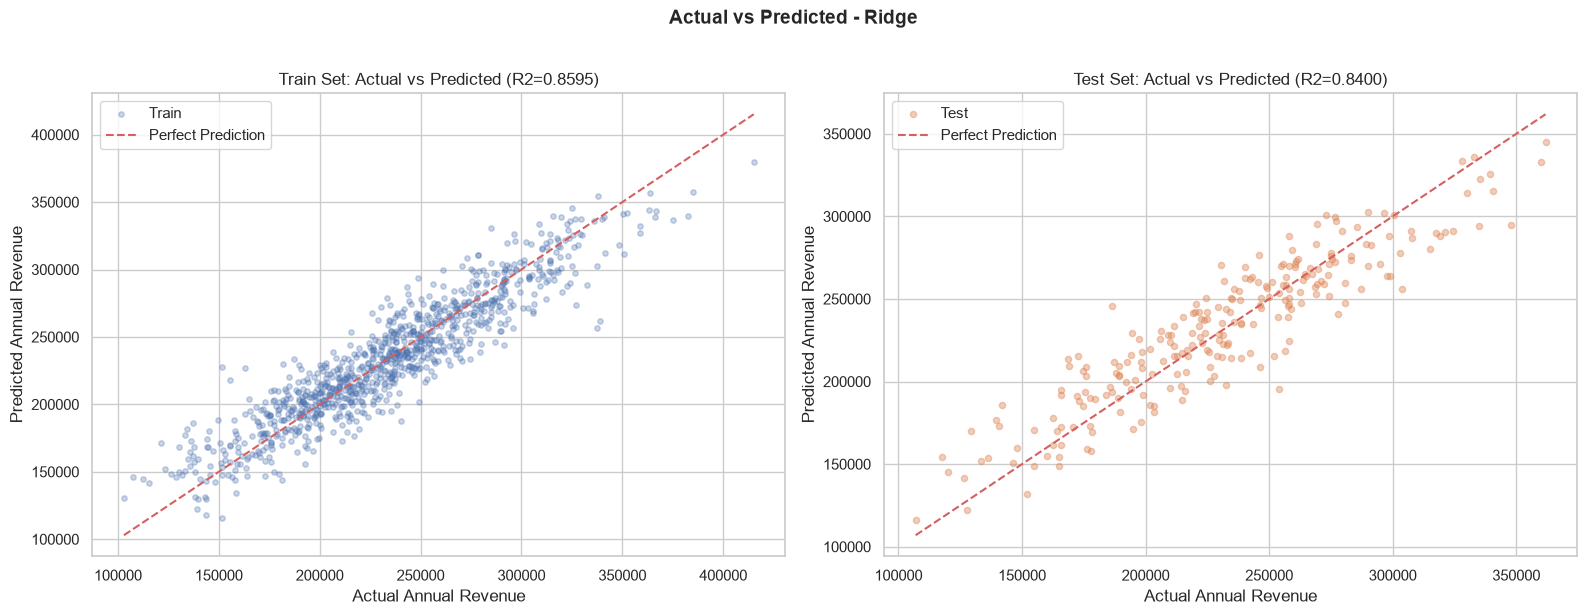

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_train, y_pred_train, alpha=0.3, s=15, color='#4C72B0', label='Train')
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Annual Revenue')
axes[0].set_ylabel('Predicted Annual Revenue')
axes[0].set_title(f'Train Set: Actual vs Predicted (R2={train_metrics["R2 Score"]:.4f})')
axes[0].legend()

axes[1].scatter(y_test, y_pred_test, alpha=0.4, s=20, color='#DD8452', label='Test')
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual Annual Revenue')
axes[1].set_ylabel('Predicted Annual Revenue')
axes[1].set_title(f'Test Set: Actual vs Predicted (R2={test_metrics["R2 Score"]:.4f})')
axes[1].legend()

plt.suptitle(f'Actual vs Predicted - {best_model_name}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 10.2 Residual Analysis

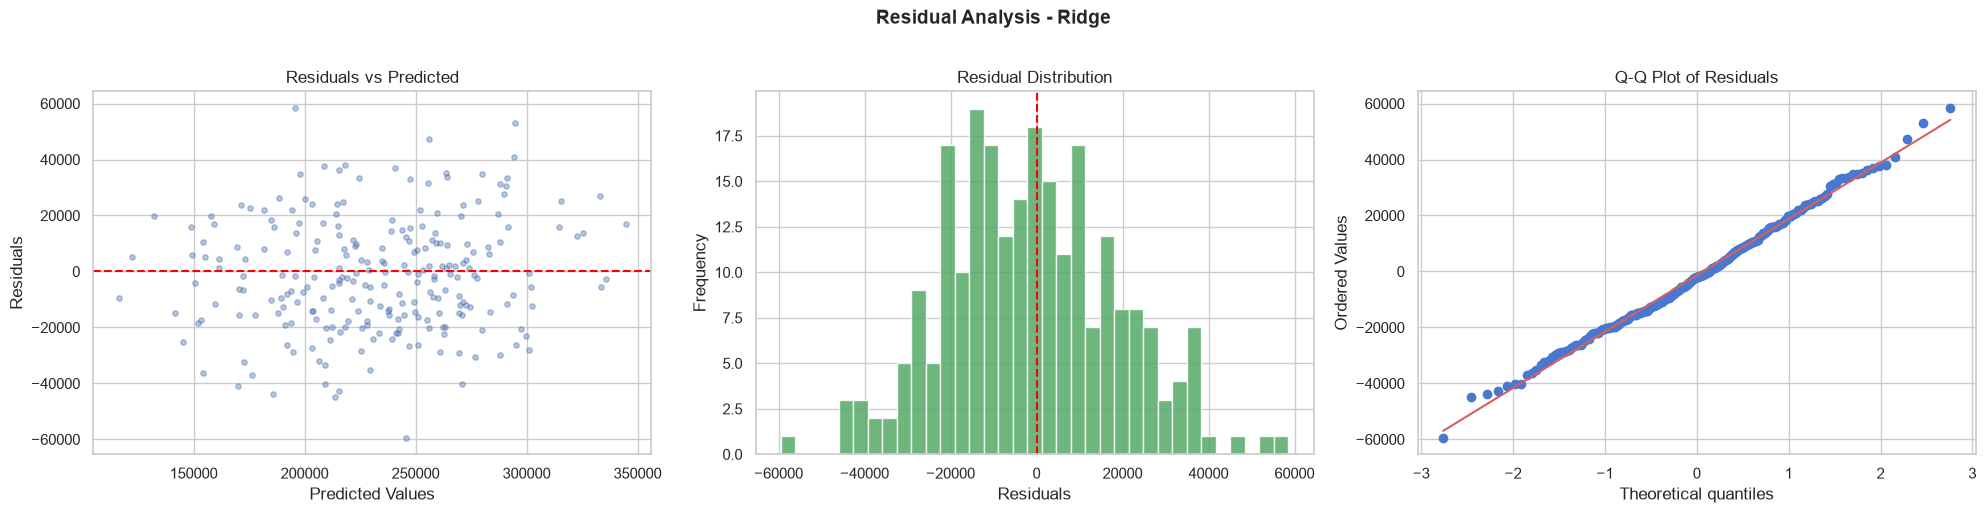

Residual Mean: -1,381.64
Residual Std: 20,026.02
Residual Skewness: 0.1779
Residual Kurtosis: -0.0819


In [32]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.4, s=15, color='#4C72B0')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=35, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.suptitle(f'Residual Analysis - {best_model_name}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Residual Mean: {residuals.mean():,.2f}')
print(f'Residual Std: {residuals.std():,.2f}')
print(f'Residual Skewness: {residuals.skew():.4f}')
print(f'Residual Kurtosis: {residuals.kurtosis():.4f}')

---
## 11. Feature Importance

Feature importance is extracted from the best model to understand which features contribute most to the prediction of annual revenue. For tree-based models, the built-in feature importance is used. For linear models, the absolute coefficients are used.

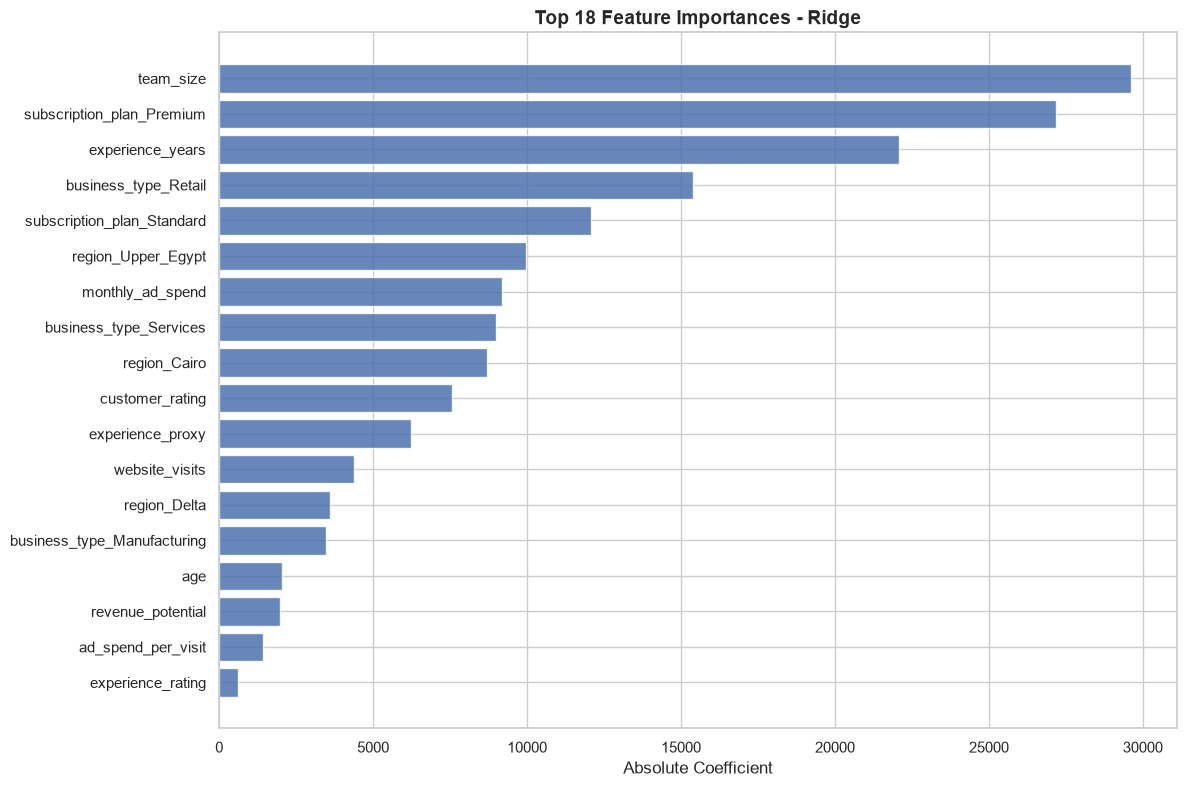

In [33]:
regressor = best_pipeline.named_steps['regressor']
pre = best_pipeline.named_steps['preprocessor']

num_feature_names = numerical_features
cat_encoder = pre.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = num_feature_names + cat_feature_names

if hasattr(regressor, 'feature_importances_'):
    importances = regressor.feature_importances_
    importance_type = 'Feature Importance (tree-based)'
elif hasattr(regressor, 'coef_'):
    importances = np.abs(regressor.coef_)
    importance_type = 'Absolute Coefficient'
else:
    importances = None
    importance_type = 'Not available'

if importances is not None:
    feat_imp_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(12, 8))
    top_n = min(20, len(feat_imp_df))
    plot_data = feat_imp_df.head(top_n).sort_values('Importance', ascending=True)
    plt.barh(plot_data['Feature'], plot_data['Importance'], color='#4C72B0', alpha=0.85)
    plt.xlabel(importance_type)
    plt.title(f'Top {top_n} Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    feat_imp_df.head(20)
else:
    print('Feature importance is not available for this model type.')

---
## 12. All Tuned Models - Test Set Evaluation

For completeness, all tuned models are evaluated on the test set to provide a final side-by-side comparison.

In [34]:
final_comparison = []

for model_name, pipeline in best_pipelines.items():
    y_pred = pipeline.predict(X_test)
    final_comparison.append({
        'Model': model_name,
        'Test R2': r2_score(y_test, y_pred),
        'Test MAE': mean_absolute_error(y_test, y_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'Test MAPE (%)': mean_absolute_percentage_error(y_test, y_pred) * 100
    })

final_df = pd.DataFrame(final_comparison).sort_values('Test R2', ascending=False).reset_index(drop=True)
final_df

,Model,Test R2,Test MAE,Test RMSE,Test MAPE (%)
0,Ridge,0.840048,16210.281123,20031.963238,7.456793
1,Lasso,0.839645,16231.051750,20057.172512,7.464843
2,Linear Regression,0.839516,16230.700525,20065.269216,7.464499


---
## 13. Save Model Artifacts

The best model pipeline, preprocessing details, feature names, evaluation metrics, and model metadata are saved to the `Model/artifacts` directory for future deployment or reproducibility.

In [35]:
artifacts_dir = 'artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

joblib.dump(best_pipeline, os.path.join(artifacts_dir, 'best_model_pipeline.joblib'))
print(f'Best model pipeline saved to: {artifacts_dir}/best_model_pipeline.joblib')

joblib.dump(preprocessor, os.path.join(artifacts_dir, 'preprocessor.joblib'))
print(f'Preprocessor saved to: {artifacts_dir}/preprocessor.joblib')

Best model pipeline saved to: artifacts/best_model_pipeline.joblib
Preprocessor saved to: artifacts/preprocessor.joblib


In [36]:
feature_info = {
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'all_encoded_features': all_feature_names,
    'target_column': 'annual_revenue'
}

with open(os.path.join(artifacts_dir, 'feature_info.json'), 'w') as f:
    json.dump(feature_info, f, indent=2)
print(f'Feature information saved to: {artifacts_dir}/feature_info.json')

Feature information saved to: artifacts/feature_info.json


In [37]:
model_metadata = {
    'best_model': best_model_name,
    'best_cv_r2': float(tuned_df.iloc[0]['Best CV R2']),
    'best_params': tuned_df.iloc[0]['Best Params'],
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'train_metrics': {k: float(v) for k, v in train_metrics.items()},
    'train_size': int(X_train.shape[0]),
    'test_size': int(X_test.shape[0]),
    'n_features': int(X.shape[1]),
    'random_state': RANDOM_STATE,
    'test_split_ratio': 0.2,
    'cv_folds': 5,
    'baseline_comparison': results_df.to_dict(orient='records'),
    'tuning_results': tuned_df.to_dict(orient='records'),
    'final_test_comparison': final_df.to_dict(orient='records')
}

with open(os.path.join(artifacts_dir, 'model_metadata.json'), 'w') as f:
    json.dump(model_metadata, f, indent=2, default=str)
print(f'Model metadata saved to: {artifacts_dir}/model_metadata.json')

Model metadata saved to: artifacts/model_metadata.json


In [38]:
if importances is not None:
    feat_imp_df.to_csv(os.path.join(artifacts_dir, 'feature_importances.csv'), index=False)
    print(f'Feature importances saved to: {artifacts_dir}/feature_importances.csv')

Feature importances saved to: artifacts/feature_importances.csv


In [39]:
print('\nAll saved artifacts:')
for f in os.listdir(artifacts_dir):
    filepath = os.path.join(artifacts_dir, f)
    size_kb = os.path.getsize(filepath) / 1024
    print(f'  {f} ({size_kb:.1f} KB)')


All saved artifacts:
  best_model_pipeline.joblib (4.5 KB)
  feature_importances.csv (0.7 KB)
  feature_info.json (0.9 KB)
  model_metadata.json (4.4 KB)
  preprocessor.joblib (4.0 KB)


---
## 14. Inference Example

A quick demonstration of how to load the saved model and make predictions on new data.

In [40]:
loaded_pipeline = joblib.load(os.path.join(artifacts_dir, 'best_model_pipeline.joblib'))

sample = X_test.head(5).copy()
predictions = loaded_pipeline.predict(sample)
actuals = y_test.head(5).values

inference_df = pd.DataFrame({
    'Actual Revenue': actuals,
    'Predicted Revenue': predictions,
    'Absolute Error': np.abs(actuals - predictions),
    'Error (%)': np.abs((actuals - predictions) / actuals) * 100
})

inference_df

,Actual Revenue,Predicted Revenue,Absolute Error,Error (%)
0,230934.84,214824.084056,16110.755944,6.976321
1,317549.93,289759.636018,27790.293982,8.751472
2,155031.37,149121.730475,5909.639525,3.811899
3,273809.13,264312.895605,9496.234395,3.468195
4,335348.58,322669.824596,12678.755404,3.780769


---
## 15. Summary

This notebook has completed the full machine learning pipeline for business revenue regression, covering the following stages:

1. Data was loaded and inspected for structure, types, and basic statistics.
2. Data cleaning addressed missing values, duplicates, and data type consistency.
3. Exploratory data analysis revealed distributions, correlations, and feature-target relationships.
4. Outliers were treated using IQR-based capping to preserve data volume.
5. Feature engineering created domain-relevant features and removed noise columns.
6. Ten regression models were trained and compared using 5-fold cross-validation.
7. The top 3 models were hyperparameter-tuned using GridSearchCV.
8. The best model was evaluated on the held-out test set with multiple metrics.
9. Residual analysis confirmed the model assumptions and identified prediction patterns.
10. Feature importances were extracted and visualized.
11. All model artifacts were saved for reproducibility and future deployment.